Data loaded:
                  Tool  Total_Scores  Count_Score_1  Count_Score_2  \
0        hash_advanced            75             29             16   
1  hash_agent_baseline            75             18             18   
2           hash_basic            75             16             14   

   Count_Score_3  Average_Score  Overall_Wins  Overall_Losses  Overall_Ties  
0             30           2.01            28              21            26  
1             39           2.28             5              32            38  
2             45           2.39             3              38            34  
Tools: ['hash_advanced', 'hash_agent_baseline', 'hash_basic']
Score 1 counts: [29, 18, 16]
Score 2 counts: [16, 18, 14]
Score 3 counts: [30, 39, 45]


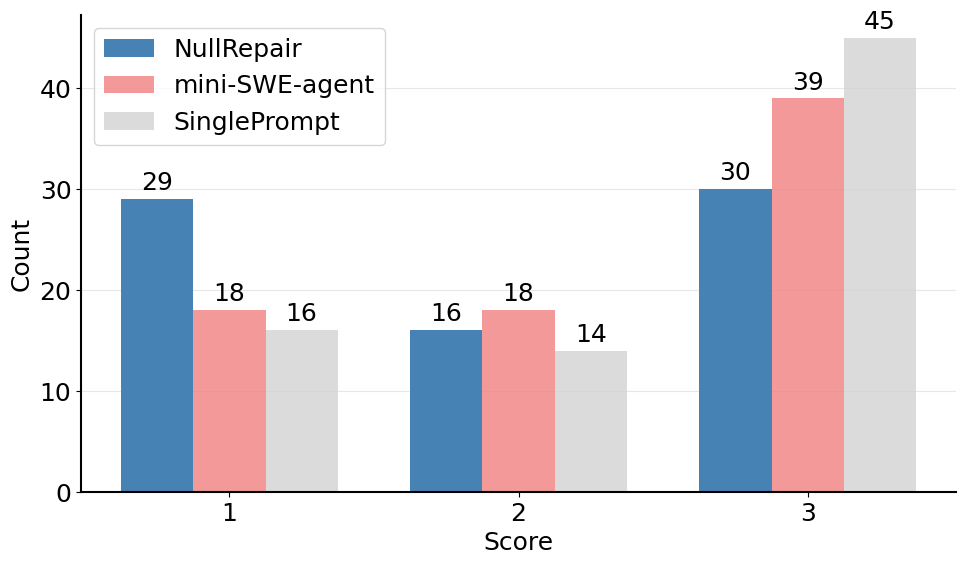

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set matplotlib parameters for larger fonts
plt.rcParams.update({'font.size': 18})

df = pd.read_csv('manual_inspection_statistics.tsv', sep='\t')
print("Data loaded:")
print(df)


tools = df['Tool'].tolist()
score_1 = df['Count_Score_1'].tolist()
score_2 = df['Count_Score_2'].tolist()
score_3 = df['Count_Score_3'].tolist()

print(f"Tools: {tools}")
print(f"Score 1 counts: {score_1}")
print(f"Score 2 counts: {score_2}")
print(f"Score 3 counts: {score_3}")

fig, ax = plt.subplots(figsize=(10, 6))

tool_labels = ['NullRepair', 'mini-SWE-agent', 'SinglePrompt']
x = np.arange(3) 
width = 0.25 

bars1 = ax.bar(x - width, [score_1[0], score_2[0], score_3[0]], width, label=tool_labels[0], color='steelblue', alpha=1)
bars2 = ax.bar(x, [score_1[1], score_2[1], score_3[1]], width, label=tool_labels[1], color='lightcoral', alpha=0.8)
bars3 = ax.bar(x + width, [score_1[2], score_2[2], score_3[2]], width, label=tool_labels[2], color='lightgray', alpha=0.8)

# Set labels with larger fonts
ax.set_xlabel('Score', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(['1', '2', '3'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)

# Make legend bigger
ax.legend(fontsize=18, frameon=True, fancybox=True)

# Remove top and right spines, keep only x and y axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

def autolabel_alt(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=18, fontweight='normal')  # Same as tick labels

autolabel_alt(bars1)
autolabel_alt(bars2)
autolabel_alt(bars3)

ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.95)
plt.tight_layout()
plt.show()
fig.savefig('plot_manual_inspection_scores.pdf', bbox_inches='tight', pad_inches=0.05)